## AutoEncoder design

AhmadReza Nopoush | sid: 610301194

Reza Mardani |sid:610301180


### 4-1

importing libraries:

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim

In [2]:
# We move our tensor to the GPU if available
if (torch.cuda.is_available()):
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
print(DEVICE)

cuda


In [3]:
train_set = torchvision.datasets.FashionMNIST(root="./", download=True,
                                              train=True,
                                              transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize(0,1)]))

test_set = torchvision.datasets.FashionMNIST(root="./", download=True,
                                              train=False,
                                              transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(0,1)]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 325kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.49MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.3MB/s]


#### dataloder definition:

In [4]:
from torch.utils.data import random_split, Dataset, DataLoader

print(f"Size of the training set: {len(train_set)}")
print(f"Size of the test set: {len(test_set)}")

# define batch_size
batch_size = 128

## Create the data loaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True)

Size of the training set: 60000
Size of the test set: 10000


#### Sample Images

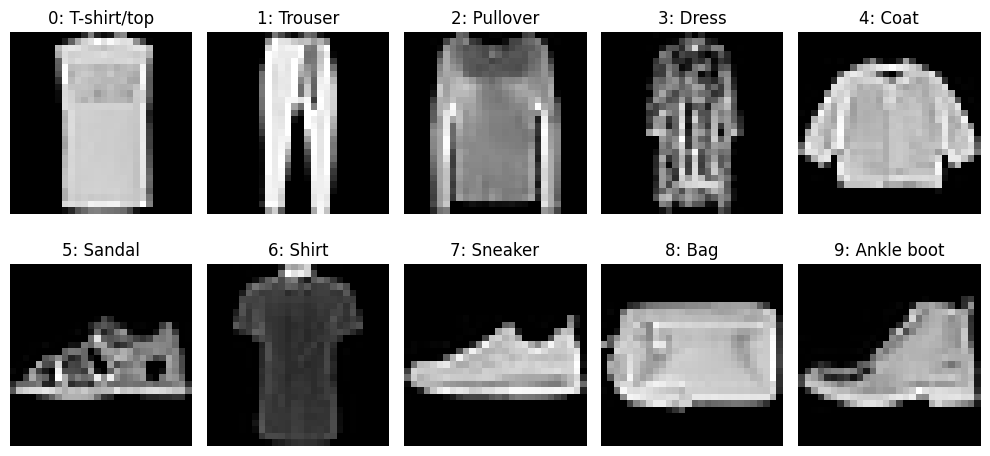

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Define class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Collect one sample per class
samples = {}
for images, labels in train_loader:
    for img, lbl in zip(images, labels):
        if lbl.item() not in samples:
            samples[lbl.item()] = img.squeeze().numpy()
        if len(samples) == 10:
            break
    if len(samples) == 10:
        break

# Create visualization
plt.figure(figsize=(10, 5))
for i, (class_idx, img) in enumerate(sorted(samples.items())):
    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{class_idx}: {class_names[class_idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### 4-2


In [6]:
import torch.nn as nn

class AutoEncoder(nn.Module):
    def __init__(self, input_dim=784, encoding_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, encoding_dim),
            nn.Tanh()  # tanh or linear to create bounded latent space
        )

        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )


    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [7]:
def train(model, train_loader, test_loader, hparams):
    # Define optimizer and criterion
    model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=hparams['lr'])
    criterion = nn.MSELoss()  # Mean Squared Error loss

    # Lists to store MSE on train_set and val_set
    train_losses = []
    test_losses = []

    for epoch in range(hparams['epochs']):
        print(f"Epoch {epoch+1}/{hparams['epochs']}")
        # Train the model for one epoch
        train_loss = fit(model, train_loader, optimizer, criterion)
        # Validate the model
        test_loss = validate(model, test_loader, criterion)

        # Store losses
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        print(f"Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

    return model, train_losses, test_losses

In [8]:
def fit(model, train_loader, optimizer, criterion):
    model.train()   # Training mode (allow weight updates)
    train_running_loss = 0.0
    counter = 0

    for i, data in enumerate(train_loader):
        counter += 1
        # Get images (ignore labels for AutoEncoder)
        images, _ = data
        images = images.to(DEVICE)
        # Flatten the images
        images = images.reshape(-1, 28*28)

        optimizer.zero_grad()   # Reset gradients
        outputs = model(images)   # Calculate outputs (reconstruction)
        loss = criterion(outputs, images)     # Calculate Loss: compare output with input
        train_running_loss += loss.item()
        loss.backward()   # Backpropagate the loss and calculate the gradients
        optimizer.step()   # Update the weights using backpropagation

    train_loss = train_running_loss / counter  # Average loss for the epoch
    return train_loss

In [9]:
def validate(model, data_loader, criterion):
    model.eval()    # Evaluation mode (do not allow weight updates)
    val_running_loss = 0.0
    counter = 0

    with torch.no_grad():   # No need to compute gradients during validation
        for i, data in enumerate(data_loader):
            counter += 1
            # Get images (ignore labels for AutoEncoder)
            images, _ = data
            images = images.to(DEVICE)
            images = images.reshape(-1, 28*28)

            outputs = model(images)
            loss = criterion(outputs, images)
            val_running_loss += loss.item()

    val_loss = val_running_loss / counter  # Average loss for validation
    return val_loss

### 4-3


In [10]:
# Initialize your model
model = AutoEncoder().to(DEVICE)
hparams = {'lr': 5e-4, 'epochs': 80}

# Train the model
model, train_losses, test_losses = train(model, train_loader, test_loader, hparams=hparams)

# After training, you can evaluate on test set
test_loss = validate(model, test_loader, nn.MSELoss())
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/80
Train Loss: 0.0327, Test Loss: 0.0212
Epoch 2/80
Train Loss: 0.0199, Test Loss: 0.0175
Epoch 3/80
Train Loss: 0.0174, Test Loss: 0.0158
Epoch 4/80
Train Loss: 0.0159, Test Loss: 0.0145
Epoch 5/80
Train Loss: 0.0147, Test Loss: 0.0134
Epoch 6/80
Train Loss: 0.0139, Test Loss: 0.0128
Epoch 7/80
Train Loss: 0.0132, Test Loss: 0.0122
Epoch 8/80
Train Loss: 0.0128, Test Loss: 0.0118
Epoch 9/80
Train Loss: 0.0124, Test Loss: 0.0115
Epoch 10/80
Train Loss: 0.0120, Test Loss: 0.0113
Epoch 11/80
Train Loss: 0.0117, Test Loss: 0.0110
Epoch 12/80
Train Loss: 0.0115, Test Loss: 0.0106
Epoch 13/80
Train Loss: 0.0112, Test Loss: 0.0105
Epoch 14/80
Train Loss: 0.0110, Test Loss: 0.0104
Epoch 15/80
Train Loss: 0.0108, Test Loss: 0.0100
Epoch 16/80
Train Loss: 0.0106, Test Loss: 0.0098
Epoch 17/80
Train Loss: 0.0105, Test Loss: 0.0097
Epoch 18/80
Train Loss: 0.0103, Test Loss: 0.0097
Epoch 19/80
Train Loss: 0.0101, Test Loss: 0.0094
Epoch 20/80
Train Loss: 0.0100, Test Loss: 0.0093
Epoch 21/

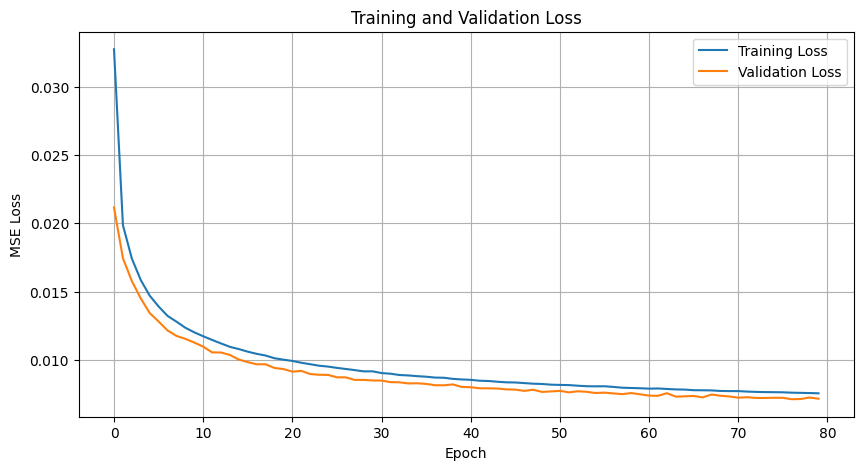


Training & Validation Losses per Epoch:
Epoch 1: Train: 0.0327 	 Test: 0.0212
Epoch 2: Train: 0.0199 	 Test: 0.0175
Epoch 3: Train: 0.0174 	 Test: 0.0158
Epoch 4: Train: 0.0159 	 Test: 0.0145
Epoch 5: Train: 0.0147 	 Test: 0.0134
Epoch 6: Train: 0.0139 	 Test: 0.0128
Epoch 7: Train: 0.0132 	 Test: 0.0122
Epoch 8: Train: 0.0128 	 Test: 0.0118
Epoch 9: Train: 0.0124 	 Test: 0.0115
Epoch 10: Train: 0.0120 	 Test: 0.0113
Epoch 11: Train: 0.0117 	 Test: 0.0110
Epoch 12: Train: 0.0115 	 Test: 0.0106
Epoch 13: Train: 0.0112 	 Test: 0.0105
Epoch 14: Train: 0.0110 	 Test: 0.0104
Epoch 15: Train: 0.0108 	 Test: 0.0100
Epoch 16: Train: 0.0106 	 Test: 0.0098
Epoch 17: Train: 0.0105 	 Test: 0.0097
Epoch 18: Train: 0.0103 	 Test: 0.0097
Epoch 19: Train: 0.0101 	 Test: 0.0094
Epoch 20: Train: 0.0100 	 Test: 0.0093
Epoch 21: Train: 0.0099 	 Test: 0.0091
Epoch 22: Train: 0.0098 	 Test: 0.0092
Epoch 23: Train: 0.0097 	 Test: 0.0090
Epoch 24: Train: 0.0096 	 Test: 0.0089
Epoch 25: Train: 0.0095 	 Test: 

In [11]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# Report loss values
print("\nTraining & Validation Losses per Epoch:")
for i in range(len(train_losses)):
    print(f"Epoch {i+1}: Train: {train_losses[i]:.4f} \t Test: {test_losses[i]:.4f}")

# Evaluate on test set
test_loss = validate(model, test_loader, nn.MSELoss())
print(f"\nFinal Test Loss: {test_loss:.4f}")

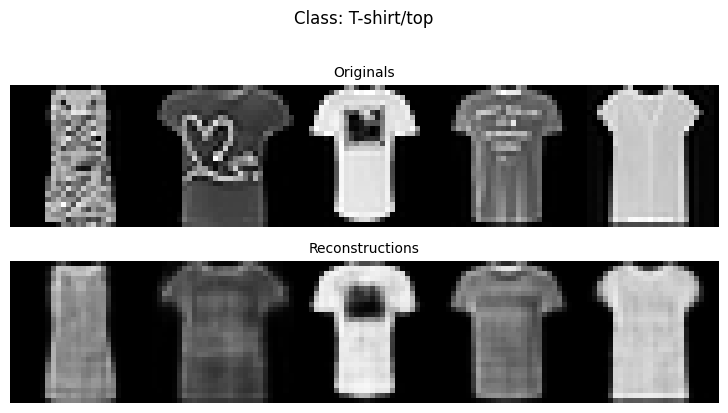

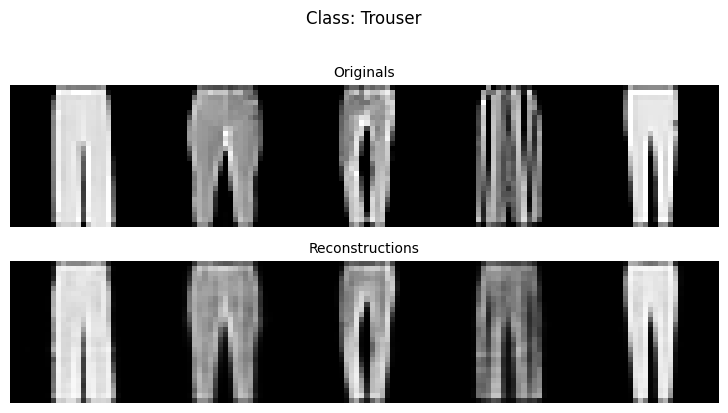

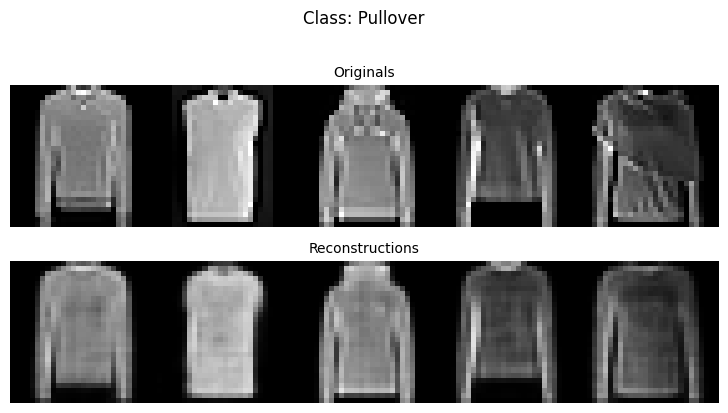

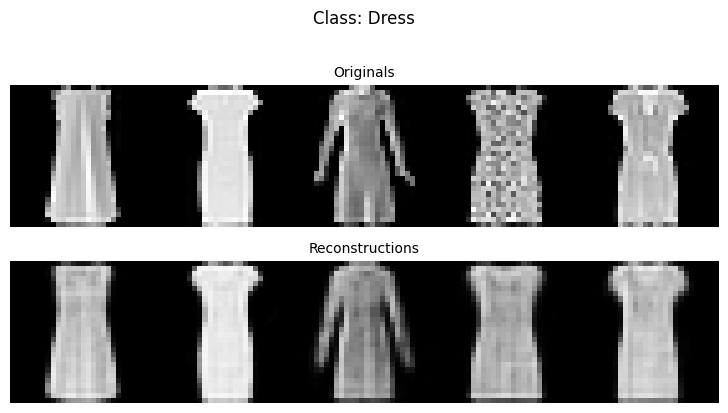

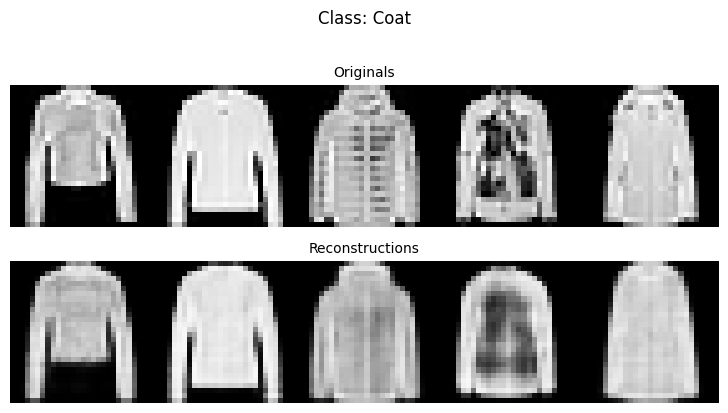

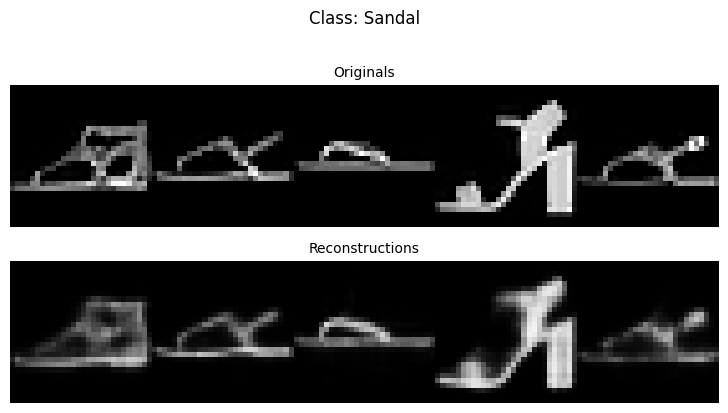

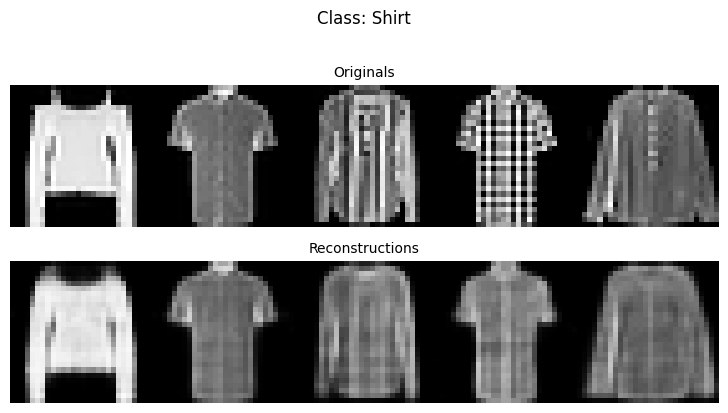

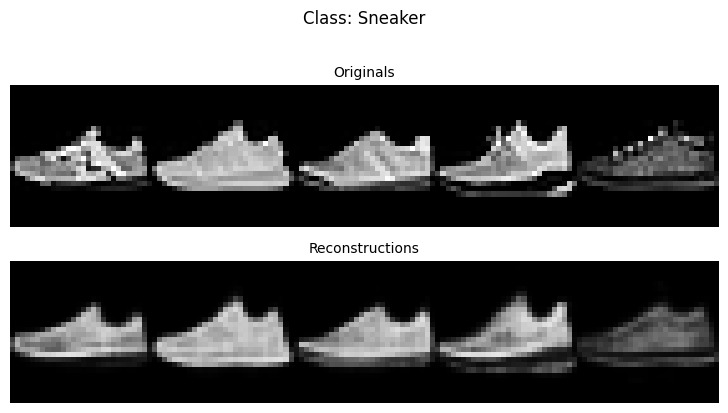

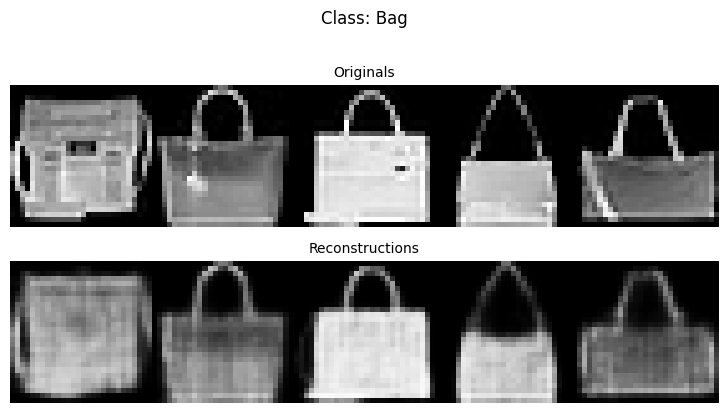

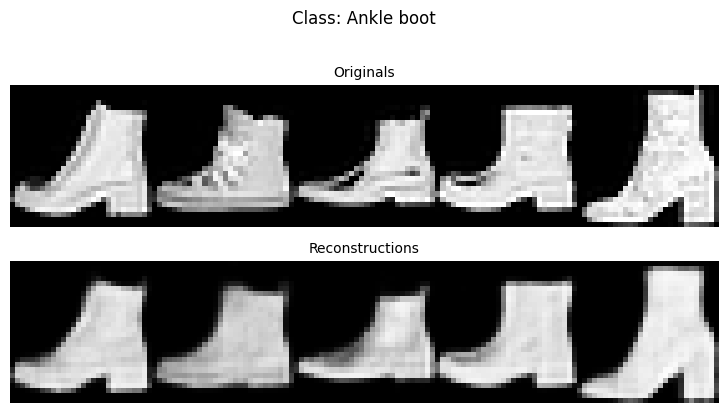

In [12]:
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import random

def visualize_class_reconstructions_separate(model, dataset, class_names, n_samples=10, device='cpu'):
    model.eval()

    for class_idx in range(10):
        # --- Collect samples for this class ---
        class_samples = [(img, label) for img, label in dataset if label == class_idx]
        selected_samples = random.sample(class_samples, n_samples)

        # --- Prepare tensors ---
        original_batch = torch.stack([img for img, _ in selected_samples]).to(device)
        original_flat = original_batch.reshape(n_samples, -1)

        # --- Reconstruct ---
        with torch.no_grad():
            reconstructed_flat = model(original_flat)
        reconstructed_batch = reconstructed_flat.reshape(n_samples, 1, 28, 28).cpu()

        # --- Make image grids ---
        original_grid = vutils.make_grid(original_batch.cpu(), nrow=n_samples, padding=0)
        reconstructed_grid = vutils.make_grid(reconstructed_batch, nrow=n_samples, padding=0)

        # --- Create a separate figure for this class ---
        fig, axes = plt.subplots(2, 1, figsize=(10, 4))
        plt.suptitle(f"Class: {class_names[class_idx]}", fontsize=12, y=1.02)

        axes[0].imshow(original_grid.permute(1, 2, 0), cmap='gray')
        axes[0].set_title("Originals", fontsize=10)
        axes[0].axis('off')

        axes[1].imshow(reconstructed_grid.permute(1, 2, 0), cmap='gray')
        axes[1].set_title("Reconstructions", fontsize=10)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

visualize_class_reconstructions_separate(model, test_set, class_names, n_samples=5, device=DEVICE)


In [13]:
from torch.utils.data import Subset

# Calculate reconstruction error per class
def calculate_reconstruction_error(model, data_loader):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for images, _ in data_loader:
            images = images.to(DEVICE)
            images_flat = images.reshape(-1, 28*28)
            outputs = model(images_flat)
            loss = nn.MSELoss(reduction='sum')(outputs, images_flat)
            total_loss += loss.item()
            total_samples += images.size(0)

    return total_loss / total_samples

# Calculate reconstruction error for each class
class_errors = {}
for class_idx in range(10):
    # Create a loader for each class
    class_indices = [i for i, (_, label) in enumerate(test_set) if label == class_idx]
    class_subset = Subset(test_set, class_indices)
    class_loader = DataLoader(class_subset, batch_size=batch_size, shuffle=False)

    error = calculate_reconstruction_error(model, class_loader)
    class_errors[class_idx] = error
    print(f"Reconstruction error for {class_names[class_idx]}: {error:.6f}")

# Compare results
print("\nReconstruction Error Comparison (sorted by error):")
sorted_errors = sorted(class_errors.items(), key=lambda x: x[1])
for class_idx, error in sorted_errors:
    print(f"{class_names[class_idx]}: {error:.6f}")



Reconstruction error for T-shirt/top: 5.304384
Reconstruction error for Trouser: 2.461986
Reconstruction error for Pullover: 5.141225
Reconstruction error for Dress: 5.097508
Reconstruction error for Coat: 4.691225
Reconstruction error for Sandal: 8.505919
Reconstruction error for Shirt: 5.983278
Reconstruction error for Sneaker: 4.017883
Reconstruction error for Bag: 9.392473
Reconstruction error for Ankle boot: 5.361738

Reconstruction Error Comparison (sorted by error):
Trouser: 2.461986
Sneaker: 4.017883
Coat: 4.691225
Dress: 5.097508
Pullover: 5.141225
T-shirt/top: 5.304384
Ankle boot: 5.361738
Shirt: 5.983278
Sandal: 8.505919
Bag: 9.392473


### 4.4

#### 4-4-1


In [14]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
import seaborn as sns
from scipy.special import comb
from scipy.optimize import linear_sum_assignment

# 4-4-1. Encode the data
print("\n4-4-1. Encoding the test data...")
model.eval()
encoded_data = []
true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        images_flat = images.reshape(-1, 28*28)
        encoded = model.encoder(images_flat)
        encoded_data.append(encoded.cpu().numpy())
        true_labels.append(labels.numpy())

encoded_data = np.concatenate(encoded_data, axis=0)
true_labels = np.concatenate(true_labels, axis=0)
print(f"Encoded data shape: {encoded_data.shape}")


4-4-1. Encoding the test data...
Encoded data shape: (10000, 64)


#### 4-4-2



4-4-2. Performing K-Means clustering...


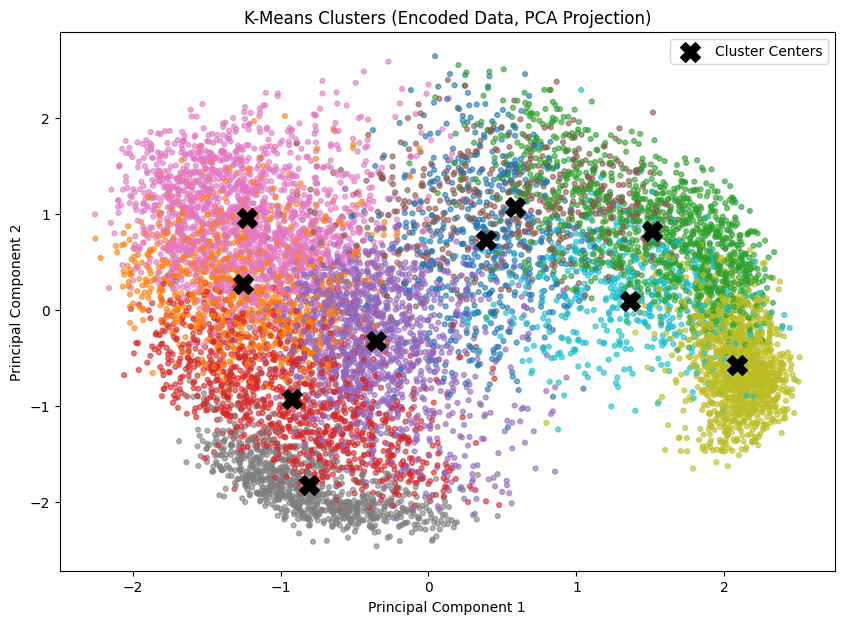

In [21]:
print("\n4-4-2. Performing K-Means clustering...")
kmeans = KMeans(n_clusters=10, random_state=42)
predicted_clusters = kmeans.fit_predict(encoded_data)

# -------------------------------------
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
encoded_pca = pca.fit_transform(encoded_data)

plt.figure(figsize=(10, 7))
plt.scatter(encoded_pca[:, 0], encoded_pca[:, 1],
            c=predicted_clusters, cmap='tab10', alpha=0.6, s=12)
plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
            pca.transform(kmeans.cluster_centers_)[:, 1],
            c='black', marker='X', s=200, label='Cluster Centers')

plt.title('K-Means Clusters (Encoded Data, PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


#### 4-4-3


4-4-3. Analyzing clusters...


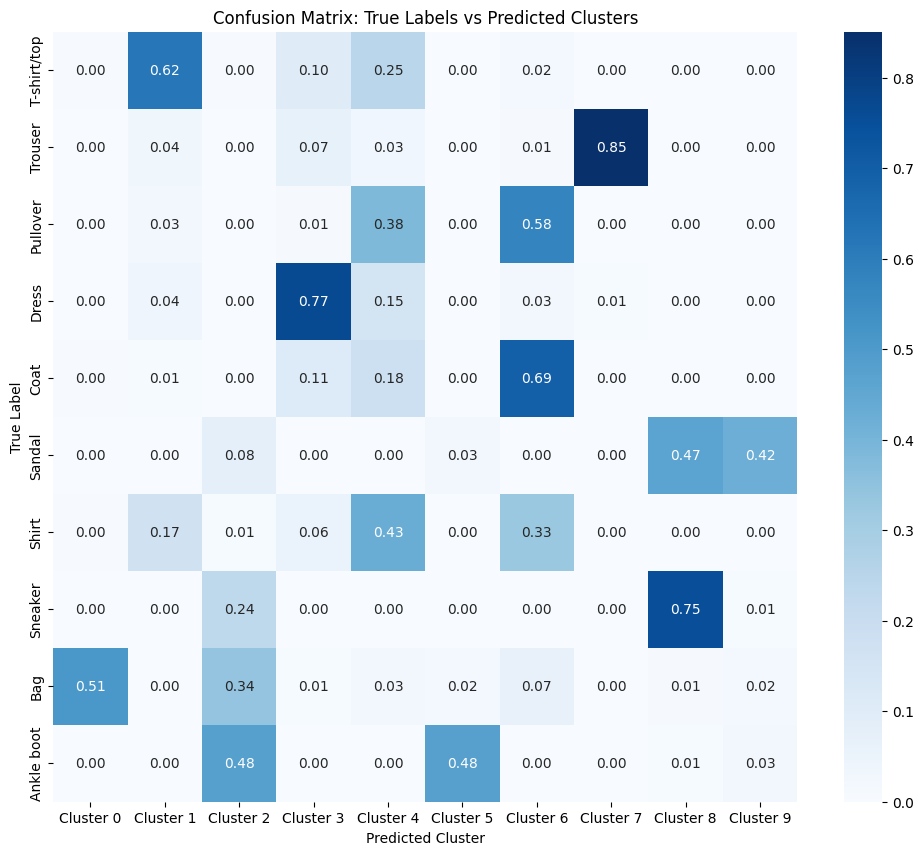

Cluster 0 mostly corresponds to: Bag (with 510 samples)
Cluster 1 mostly corresponds to: T-shirt/top (with 619 samples)
Cluster 2 mostly corresponds to: Ankle boot (with 482 samples)
Cluster 3 mostly corresponds to: Dress (with 765 samples)
Cluster 4 mostly corresponds to: Shirt (with 430 samples)
Cluster 5 mostly corresponds to: Ankle boot (with 478 samples)
Cluster 6 mostly corresponds to: Coat (with 694 samples)
Cluster 7 mostly corresponds to: Trouser (with 851 samples)
Cluster 8 mostly corresponds to: Sneaker (with 754 samples)
Cluster 9 mostly corresponds to: Sandal (with 424 samples)


In [16]:
# 4-4-3. Cluster Analysis
print("\n4-4-3. Analyzing clusters...")
conf_mat = confusion_matrix(true_labels, predicted_clusters)

# Normalize confusion matrix for better visualization
conf_mat_norm = conf_mat.astype('float') / conf_mat.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in range(10)],
            yticklabels=class_names)
plt.title('Confusion Matrix: True Labels vs Predicted Clusters')
plt.xlabel('Predicted Cluster')
plt.ylabel('True Label')
plt.show()

# Find which original class each cluster mostly corresponds to
cluster_to_class = {}
for cluster in range(10):
    class_idx = np.argmax(conf_mat[:, cluster])
    cluster_to_class[cluster] = class_idx
    print(f"Cluster {cluster} mostly corresponds to: {class_names[class_idx]} (with {conf_mat[class_idx, cluster]} samples)")



#### 4-4-4


4-4-4. Visualizing with t-SNE...


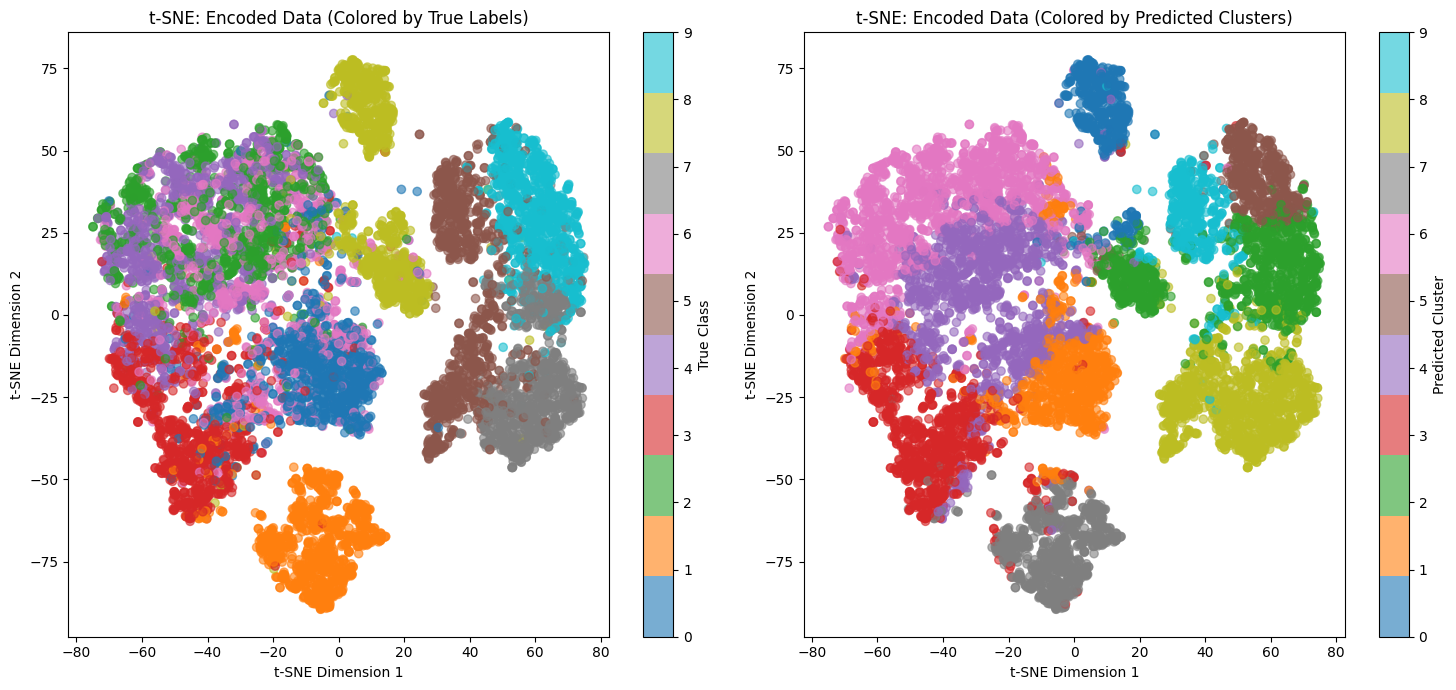

In [17]:





# 4-4-4. Dimensionality Reduction and t-SNE Visualization
print("\n4-4-4. Visualizing with t-SNE...")

# t-SNE for encoded data
tsne_encoded = TSNE(n_components=2, random_state=42, perplexity=30)
encoded_tsne = tsne_encoded.fit_transform(encoded_data)

# Plot t-SNE colored by true labels
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
scatter = plt.scatter(encoded_tsne[:, 0], encoded_tsne[:, 1], c=true_labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='True Class')
plt.title('t-SNE: Encoded Data (Colored by True Labels)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# Plot t-SNE colored by predicted clusters
plt.subplot(1, 2, 2)
scatter = plt.scatter(encoded_tsne[:, 0], encoded_tsne[:, 1], c=predicted_clusters, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Predicted Cluster')
plt.title('t-SNE: Encoded Data (Colored by Predicted Clusters)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()

#### 4-4-5



4-4-5. Comparing with raw data...
Raw data shape: (10000, 784)


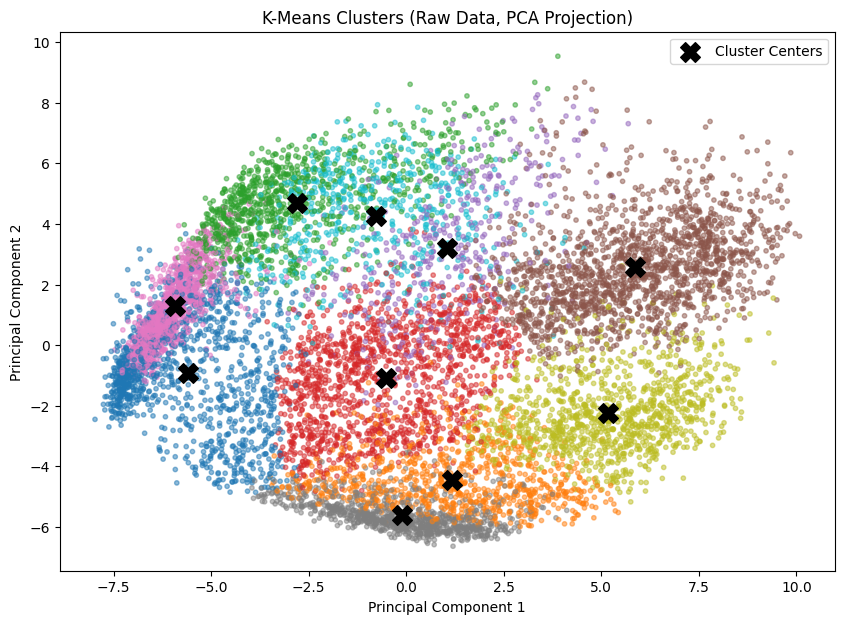

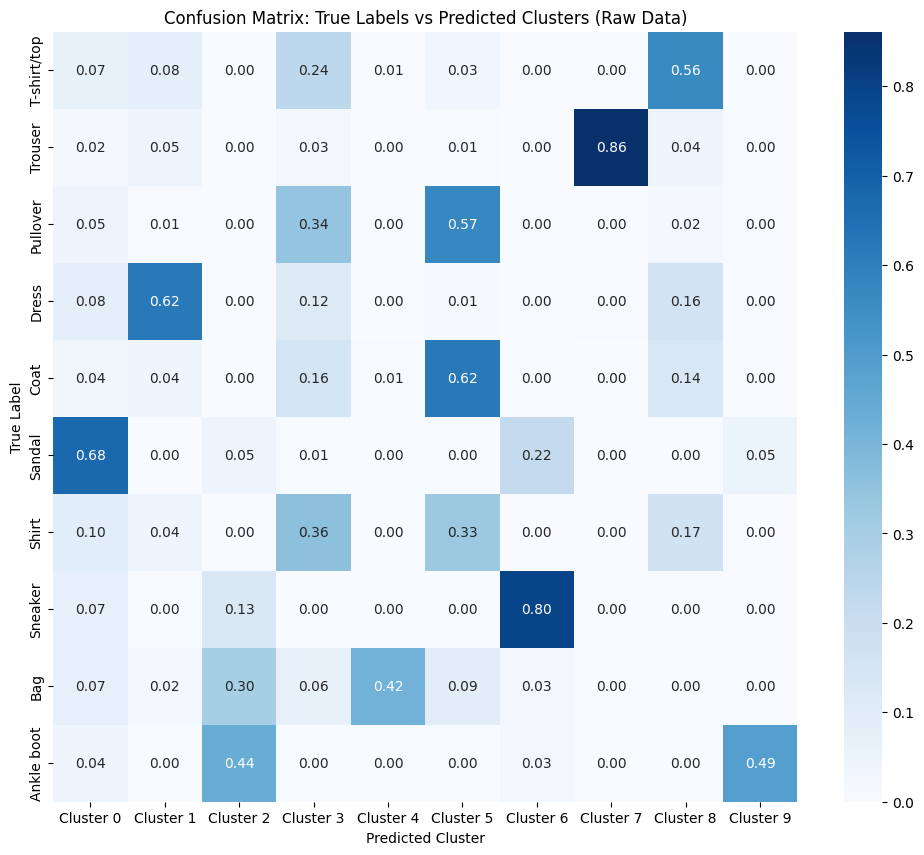

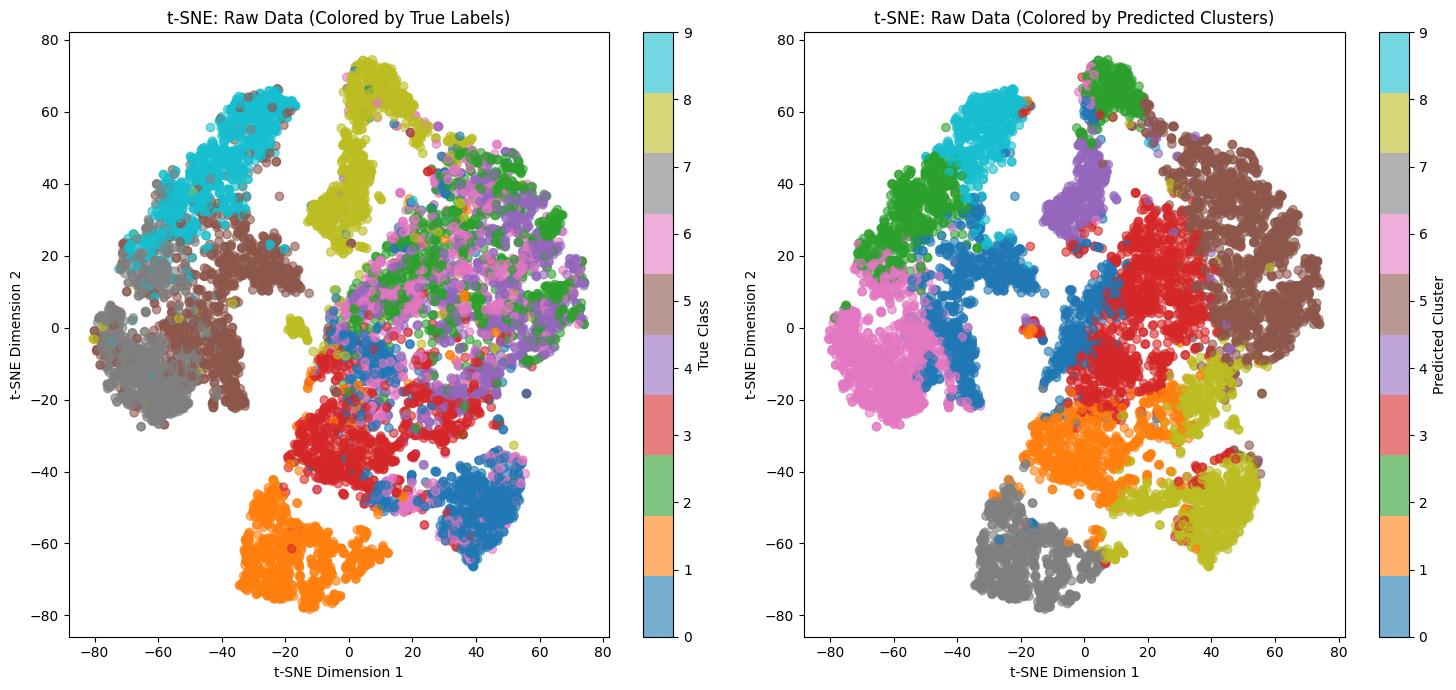

In [20]:
# 4-4-5. Comparison with Raw Data
print("\n4-4-5. Comparing with raw data...")

# Prepare raw test data
raw_data = []
raw_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        images_flat = images.reshape(-1, 28*28)
        raw_data.append(images_flat.cpu().numpy())
        raw_labels.append(labels.numpy())

raw_data = np.concatenate(raw_data, axis=0)
raw_labels = np.concatenate(raw_labels, axis=0)
print(f"Raw data shape: {raw_data.shape}")

# Perform K-Means on raw data
kmeans_raw = KMeans(n_clusters=10, random_state=42)
predicted_clusters_raw = kmeans_raw.fit_predict(raw_data)

# -------------------------------------
# 🌀 Plot K-Means clustering structure
# -------------------------------------
plt.figure(figsize=(10, 7))
# Reduce to 2D for visualization using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
raw_pca = pca.fit_transform(raw_data)

plt.scatter(raw_pca[:, 0], raw_pca[:, 1], c=predicted_clusters_raw, cmap='tab10', alpha=0.5, s=10)
plt.scatter(pca.transform(kmeans_raw.cluster_centers_)[:, 0],
            pca.transform(kmeans_raw.cluster_centers_)[:, 1],
            c='black', s=200, marker='X', label='Cluster Centers')

plt.title('K-Means Clusters (Raw Data, PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# -------------------------------------
# Confusion Matrix (Raw Data)
# -------------------------------------
conf_mat_raw = confusion_matrix(raw_labels, predicted_clusters_raw)
conf_mat_raw_norm = conf_mat_raw.astype('float') / conf_mat_raw.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat_raw_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in range(10)],
            yticklabels=class_names)
plt.title('Confusion Matrix: True Labels vs Predicted Clusters (Raw Data)')
plt.xlabel('Predicted Cluster')
plt.ylabel('True Label')
plt.show()

# -------------------------------------
# t-SNE Visualization (Raw Data)
# -------------------------------------
tsne_raw = TSNE(n_components=2, random_state=42, perplexity=30)
raw_tsne = tsne_raw.fit_transform(raw_data)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
scatter = plt.scatter(raw_tsne[:, 0], raw_tsne[:, 1], c=raw_labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='True Class')
plt.title('t-SNE: Raw Data (Colored by True Labels)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.subplot(1, 2, 2)
scatter = plt.scatter(raw_tsne[:, 0], raw_tsne[:, 1], c=predicted_clusters_raw, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Predicted Cluster')
plt.title('t-SNE: Raw Data (Colored by Predicted Clusters)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.tight_layout()
plt.show()


#### 4-4-6


In [19]:


# 4-4-6. Clustering Quality Evaluation
print("\n4-4-6. Evaluating clustering quality...")

# Implement Adjusted Rand Index (ARI)
def adjusted_rand_index(labels_true, labels_pred):
    # Create contingency table
    contingency = confusion_matrix(labels_true, labels_pred)

    # Sum over rows and columns
    a = contingency.sum(axis=1)
    b = contingency.sum(axis=0)

    # Total number of pairs
    n_pairs = comb(len(labels_true), 2)

    # Sum of squares of contingency table
    sum_sq_contingency = (contingency ** 2).sum()

    # Sum of squares of row and column sums
    sum_sq_a = (a ** 2).sum()
    sum_sq_b = (b ** 2).sum()

    # Expected index
    expected_index = sum_sq_a * sum_sq_b / (len(labels_true) ** 2)

    # Maximum index
    max_index = 0.5 * (sum_sq_a + sum_sq_b)

    # Calculate ARI
    if max_index == expected_index:
        return 0.0

    ari = (sum_sq_contingency - expected_index) / (max_index - expected_index)
    return ari

# Implement Adjusted Mutual Information (AMI)
def adjusted_mutual_info(labels_true, labels_pred):
    # Create contingency table
    contingency = confusion_matrix(labels_true, labels_pred)

    # Calculate mutual information
    n_samples = len(labels_true)
    n_classes = contingency.shape[0]
    n_clusters = contingency.shape[1]

    # Calculate probabilities
    p_ij = contingency / n_samples
    p_i = p_ij.sum(axis=1)
    p_j = p_ij.sum(axis=0)

    # Calculate mutual information
    mi = 0.0
    for i in range(n_classes):
        for j in range(n_clusters):
            if p_ij[i, j] > 0:
                mi += p_ij[i, j] * np.log(p_ij[i, j] / (p_i[i] * p_j[j]))

    # Calculate expected mutual information
    n_samples_a = contingency.sum(axis=1)
    n_samples_b = contingency.sum(axis=0)

    # Calculate expected MI using permutation
    n_samples = len(labels_true)
    n_samples_a = contingency.sum(axis=1)
    n_samples_b = contingency.sum(axis=0)

    # Calculate expected MI
    emi = 0.0
    for i in range(n_classes):
        for j in range(n_clusters):
            # Calculate the probability of agreement by chance
            # Using the hypergeometric distribution
            n_ij = contingency[i, j]
            n_i = n_samples_a[i]
            n_j = n_samples_b[j]

            # Calculate the probability of getting at least n_ij agreements by chance
            # This is a simplified approximation
            prob = (n_i * n_j) / (n_samples * (n_samples - 1))
            emi += prob * np.log(prob + 1e-10) if prob > 0 else 0

    # Calculate AMI
    # Normalized mutual information
    nmi = mi / (np.sqrt(np.sum(p_i * np.log(p_i + 1e-10)) * np.sum(p_j * np.log(p_j + 1e-10))) + 1e-10)

    # Adjusted mutual information
    ami = (mi - emi) / (np.sqrt(np.sum(p_i * np.log(p_i + 1e-10)) * np.sum(p_j * np.log(p_j + 1e-10))) - emi + 1e-10)

    return ami

# Calculate metrics for encoded data
ari_encoded = adjusted_rand_index(true_labels, predicted_clusters)
ami_encoded = adjusted_mutual_info(true_labels, predicted_clusters)

# Calculate metrics for raw data
ari_raw = adjusted_rand_index(raw_labels, predicted_clusters_raw)
ami_raw = adjusted_mutual_info(raw_labels, predicted_clusters_raw)

# Print results
print("\nClustering Quality Evaluation:")
print("Encoded Data:")
print(f"  Adjusted Rand Index (ARI): {ari_encoded:.4f}")
print(f"  Adjusted Mutual Information (AMI): {ami_encoded:.4f}")

print("\nRaw Data:")
print(f"  Adjusted Rand Index (ARI): {ari_raw:.4f}")
print(f"  Adjusted Mutual Information (AMI): {ami_raw:.4f}")

# Check if results meet criteria
print("\nCriteria Check:")
print(f"Encoded Data ARI >= 0.3: {'✓' if ari_encoded >= 0.3 else '✗'} ({ari_encoded:.4f})")
print(f"Encoded Data AMI >= 0.5: {'✓' if ami_encoded >= 0.5 else '✗'} ({ami_encoded:.4f})")
print(f"Raw Data ARI >= 0.3: {'✓' if ari_raw >= 0.3 else '✗'} ({ari_raw:.4f})")
print(f"Raw Data AMI >= 0.5: {'✓' if ami_raw >= 0.5 else '✗'} ({ami_raw:.4f})")

# Comparison
print("\nComparison:")
print(f"ARI improvement: {ari_encoded - ari_raw:.4f}")
print(f"AMI improvement: {ami_encoded - ami_raw:.4f}")


4-4-6. Evaluating clustering quality...

Clustering Quality Evaluation:
Encoded Data:
  Adjusted Rand Index (ARI): 0.3992
  Adjusted Mutual Information (AMI): 0.8590

Raw Data:
  Adjusted Rand Index (ARI): 0.3917
  Adjusted Mutual Information (AMI): 0.8445

Criteria Check:
Encoded Data ARI >= 0.3: ✓ (0.3992)
Encoded Data AMI >= 0.5: ✓ (0.8590)
Raw Data ARI >= 0.3: ✓ (0.3917)
Raw Data AMI >= 0.5: ✓ (0.8445)

Comparison:
ARI improvement: 0.0075
AMI improvement: 0.0145
